# Practice 3 - Manuel Isaac Gonzalez Chi
# Machine Learning UADY
# Support Vector Machines (SVM) and Multilayer Perceptron (MLP)

## Importing Libraries

In [ ]:
from sklearn.datasets import load_breast_cancer # Importing the breast cancer wisconsin dataset from sklearn.datasets
from sklearn.model_selection import train_test_split # To split the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler # To standardize the features by removing the mean and scaling to unit variance
from sklearn.svm import SVC # Importing the Support Vector Classifier
from sklearn.neural_network import MLPClassifier # Importing the Multi-layer Perceptron classifier
from sklearn.metrics import classification_report # To evaluate the performance of the classifiers by generating a classification report
from sklearn.metrics import ConfusionMatrixDisplay # To visualize the confusion matrix for the classifiers


## Loading Dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
print(X.shape, y.shape)

(569, 30) (569,)


In [35]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## Splitting data into Train and Test sets

The 80 percent of the data will be used for training the modeles, while the 20 percent left for testing, with a fixed random state to reproduce the same split in all models.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Data split into training and testing sets.
Training set size: 455
Testing set size: 114


## Scaling Data

This transforms the dataset so that each feature has zero mean and a standard deviation of one. This normalization ensures that all input variables are on the same scale, which is especially important for models such as SVMs and neural networks, since it helps improve convergence during training and prevents features with larger numeric ranges from dominating the learning process.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

## Fitting models

## Support Vector Machine Classifier

Different kernel functions were used to transform the input space and allow the SVM to learn different types of decision boundaries.

### Linear Kernel

The linear kernel assumes a linear separation:
$
K(x_i,x_j) = x_i^T x_j
$

In [5]:
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)
print(classification_report(y_test, linear_svm.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Polynomial Kernel

The polynomial kernel models nonlinear interactions between features: $ K(x_i,x_j) = (\gamma x_i^T x_j + r)^d $

In [6]:
poly_svm = SVC(kernel='poly', degree=3, random_state=42)
poly_svm.fit(X_train_scaled, y_train)
print(classification_report(y_test, poly_svm.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       1.00      0.65      0.79        43
           1       0.83      1.00      0.90        71

    accuracy                           0.87       114
   macro avg       0.91      0.83      0.85       114
weighted avg       0.89      0.87      0.86       114



### RBF Kernel

The Radial Basis Function (RBF) kernel captures highly nonlinear relationships based on distance: $ K(x_i,x_j) = \exp(-\gamma \|x_i - x_j\|^2) $

In [7]:
radial_svm = SVC(kernel='rbf', random_state=42)
radial_svm.fit(X_train_scaled, y_train)
print(classification_report(y_test, radial_svm.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Sigmoid Kernel

The Sigmoid Kernel employs the hyperbolic tangent function to behave like a neural activation: $ K(x_i,x_j) = \tanh(\gamma x_i^T x_j + r) $

In [8]:
sigmoid_svm = SVC(kernel='sigmoid', random_state=42)
sigmoid_svm.fit(X_train_scaled, y_train)
print(classification_report(y_test, sigmoid_svm.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Multilayer Perceptron

### One hidden layer

In [19]:
nn_1 = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
nn_1.fit(X_train_scaled, y_train)
print(classification_report(y_test, nn_1.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Two hidden layers

In [18]:
nn_2 = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=42)
nn_2.fit(X_train_scaled, y_train)
print(classification_report(y_test, nn_2.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### Three hidden layers

In [16]:
nn_3 = MLPClassifier(hidden_layer_sizes=(64, 64, 64), max_iter=1000, random_state=42)
nn_3.fit(X_train_scaled, y_train)
print(classification_report(y_test, nn_3.predict(scaler.transform(X_test))))


              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Four hidden layers

In [12]:
nn_4 = MLPClassifier(hidden_layer_sizes=(64, 64, 64, 64), max_iter=1000, random_state=42)
nn_4.fit(X_train_scaled, y_train)
print(classification_report(y_test, nn_4.predict(scaler.transform(X_test))))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Comparison Table

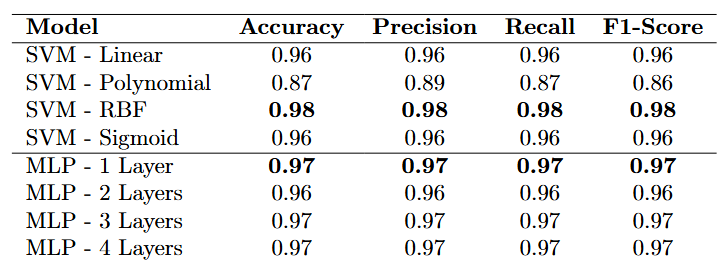

## Visualization

### Bar Chart

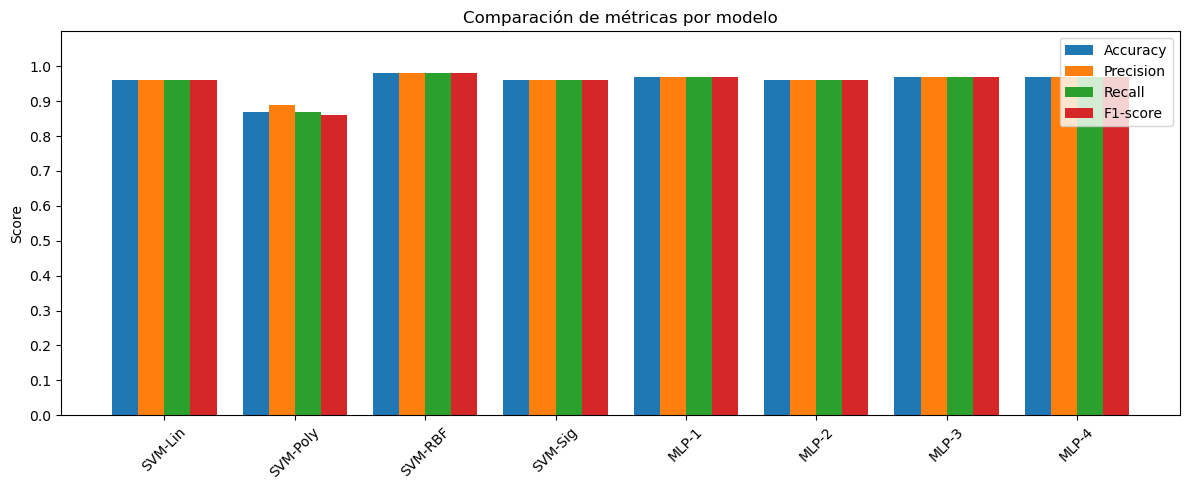

In [28]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "SVM-Lin", "SVM-Poly", "SVM-RBF", "SVM-Sig",
    "MLP-1", "MLP-2", "MLP-3", "MLP-4"
]

accuracy  = [0.96, 0.87, 0.98, 0.96, 0.97, 0.96, 0.97, 0.97]
precision = [0.96, 0.89, 0.98, 0.96, 0.97, 0.96, 0.97, 0.97]
recall    = [0.96, 0.87, 0.98, 0.96, 0.97, 0.96, 0.97, 0.97]
f1        = [0.96, 0.86, 0.98, 0.96, 0.97, 0.96, 0.97, 0.97]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,5))

plt.bar(x - 1.5*width, accuracy,  width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall,    width, label='Recall')
plt.bar(x + 1.5*width, f1,        width, label='F1-score')

plt.xticks(x, models, rotation=45)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.ylabel("Score")
plt.title("Comparación de métricas por modelo")
plt.ylim(0, 1.1)

plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix of the best models

### Radial Basis Function Kernel SVM

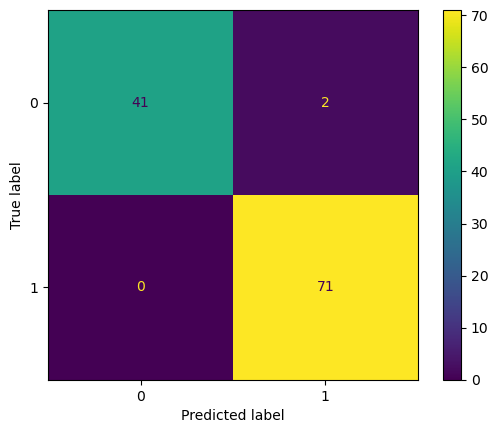

In [13]:
ConfusionMatrixDisplay.from_estimator(radial_svm, scaler.transform(X_test), y_test)

### One layer MLP

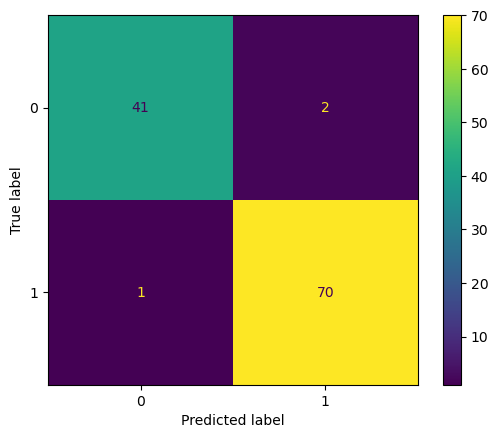

In [14]:
ConfusionMatrixDisplay.from_estimator(nn_3, scaler.transform(X_test), y_test)

## Analysis

### Which SVM kernel achieved the best results and why do you think that is the case?

The Radial Basis Function kernel showed the highest metrics (0.98) compared to the other ones. In practice, since it is based on distance similarity between samples, the RBF kernel is suitable for data with complex distributions, which may imply that the case is not linearly separable. That could be precisely why the other kernels did not performed better due to their lack of flexibility in those cases. In addition, neuron-like kernels might not work well due to the unbalance between the positive and negative samples.

### How does increasing the number of hidden layers affect the MLP performance? Is deeper always better?

Increasing the number of hidden layers slightly improved performance from one layer to deeper architectures, but the improvement quickly stabilized. The models with three and four layers achieved similar results to the one-layer MLP, indicating that additional depth did not significantly enhance performance. This suggests that the dataset may not require a highly complex model. In addition, increasing the number of neurons (and hence the complexity) is more likely to overfit the model if not required, as well as increase the computational cost to train, test, and predict

### Overall, which family of models (SVM or MLP) performed better on this dataset? What factors might explain the difference?

As observed, MLP architectures showed in average better results than the set of SVM classifiers, except for the RBF kernel, which showed the best results. The SVM with RBF achieved the highest accuracy, while MLP models produced competitive but slightly lower results. This difference may be explained by the dataset size and feature characteristics, since the number of data is small (455) and then training the models with few instances affect the performance of the models; however, SVM classifiers usually work better in these cases, and due to the complexity of data, RBF kernel handles complex boundaries; in constrast, MLP addresses the complexity of data with the neural-activation approach, in which the sigmoid SVM kernel is based, but because of the small number of training data and unbalance between classes, adding more features to the model becomes eventually worse. 